In [1]:

import os
from pathlib import Path
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/tmp")
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

# Print-friendly plotting helpers for black-and-white Xerox copies.
PRINT_HATCHES = ["", "///", "\\\\", "xx", "..", "++", "--", "oo", "**", "OO"]
PRINT_MARKERS = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
PRINT_GRAYS = ["#111111", "#444444", "#777777", "#AAAAAA", "#DDDDDD"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#111111",
    "axes.labelcolor": "#111111",
    "xtick.color": "#111111",
    "ytick.color": "#111111",
    "grid.color": "#D0D0D0",
})

def print_palette(n):
    if n <= 0:
        return []
    return [PRINT_GRAYS[i % len(PRINT_GRAYS)] for i in range(n)]

def apply_bar_hatches(ax, hatches=PRINT_HATCHES):
    for i, patch in enumerate(ax.patches):
        patch.set_facecolor("white")
        patch.set_edgecolor("#111111")
        patch.set_linewidth(1.0)
        patch.set_hatch(hatches[i % len(hatches)])
    return ax

def boxplot_print(data, x, y, ax=None, showfliers=False):
    ax = ax or plt.gca()
    sns.boxplot(
        data=data,
        x=x,
        y=y,
        ax=ax,
        color="white",
        showfliers=showfliers,
        boxprops={"facecolor": "white", "edgecolor": "#111111", "linewidth": 1.0},
        medianprops={"color": "#111111", "linewidth": 1.3},
        whiskerprops={"color": "#111111", "linewidth": 1.0},
        capprops={"color": "#111111", "linewidth": 1.0},
    )
    for i, patch in enumerate(ax.patches):
        patch.set_hatch(PRINT_HATCHES[i % len(PRINT_HATCHES)])
        patch.set_edgecolor("#111111")
    return ax

def scatter_with_markers(data, x, y, hue, title, xlabel=None, ylabel=None, max_legend_items=12):
    fig, ax = plt.subplots(figsize=(8.5, 6))
    labels = data[hue].astype("string").fillna("<NA>")
    order = labels.value_counts().index.tolist()
    if len(order) > max_legend_items:
        keep = set(order[:max_legend_items - 1])
        plot_data = data.copy()
        plot_data[hue] = labels.where(labels.isin(keep), "Other")
        labels = plot_data[hue].astype("string")
        order = labels.value_counts().index.tolist()
    else:
        plot_data = data.copy()
        plot_data[hue] = labels

    for i, label in enumerate(order):
        subset = plot_data[plot_data[hue].astype("string") == str(label)]
        ax.scatter(
            subset[x],
            subset[y],
            marker=PRINT_MARKERS[i % len(PRINT_MARKERS)],
            facecolors="none",
            edgecolors="#111111",
            linewidths=0.75,
            alpha=0.7,
            s=24,
            label=str(label),
        )
    ax.set_title(title)
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)
    ax.legend(title=hue, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    return ax


RANDOM_STATE = 42
PLOT_SAMPLE_SIZE = 50_000

def find_data_file(filename):
    candidates = [
        Path(filename),
        Path("eda") / filename,
        Path("..") / "eda" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename}. Tried: {candidates}")

def display_basic_profile(df, target_col=None):
    memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    profile = pd.DataFrame({
        "metric": ["rows", "columns", "memory_mb", "duplicate_rows", "total_missing_cells"],
        "value": [len(df), df.shape[1], round(memory_mb, 2), int(df.duplicated().sum()), int(df.isna().sum().sum())],
    })
    display(profile)
    if target_col and target_col in df.columns:
        target_summary = (
            df[target_col]
            .value_counts(dropna=False)
            .rename_axis(target_col)
            .reset_index(name="count")
        )
        target_summary["percent"] = (target_summary["count"] / len(df) * 100).round(2)
        display(target_summary)

def get_numeric_columns(df, exclude=None):
    exclude = set(exclude or [])
    return [c for c in df.select_dtypes(include=np.number).columns if c not in exclude]

def get_categorical_columns(df, exclude=None):
    exclude = set(exclude or [])
    return [c for c in df.select_dtypes(include=["object", "string", "category", "bool"]).columns if c not in exclude]

def sampled(df, n=PLOT_SAMPLE_SIZE):
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=RANDOM_STATE)

def plot_target_distribution(df, target_col, title):
    order = df[target_col].value_counts(dropna=False).index
    plt.figure(figsize=(8, 4.5))
    ax = sns.countplot(data=df, x=target_col, order=order, color="white", edgecolor="#111111")
    apply_bar_hatches(ax)
    ax.set_title(title)
    ax.set_xlabel(target_col)
    ax.set_ylabel("Rows")
    ax.tick_params(axis="x", rotation=30)
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", fontsize=9)
    plt.tight_layout()
    plt.show()

def plot_missing_values(df):
    missing = df.isna().sum().sort_values(ascending=False)
    missing = missing[missing > 0].head(20)
    if missing.empty:
        display(Markdown("No missing values after loading and standard cleanup."))
        return
    plt.figure(figsize=(10, max(3, len(missing) * 0.3)))
    ax = sns.barplot(x=missing.values, y=missing.index, color="white", edgecolor="#111111")
    apply_bar_hatches(ax)
    plt.title("Top columns by missing value count")
    plt.xlabel("Missing cells")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

def plot_numeric_distributions(df, columns, title):
    if not columns:
        display(Markdown("No numeric columns available for distribution plots."))
        return
    sample = sampled(df)
    n_cols = min(3, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, columns):
        values = pd.to_numeric(sample[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        if values.empty:
            ax.set_visible(False)
            continue
        label = col
        if values.min() >= 0 and values.quantile(0.99) > max(values.median() * 10, 10):
            values = np.log1p(values)
            label = f"log1p({col})"
        sns.histplot(values, bins=40, kde=True, ax=ax, color="#D9D9D9", edgecolor="#111111", line_kws={"color": "#111111"})
        ax.set_title(col)
        ax.set_xlabel(label)
    for ax in axes[len(columns):]:
        ax.set_visible(False)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_categorical_top_counts(df, columns, title):
    if not columns:
        display(Markdown("No categorical columns available for count plots."))
        return
    n_cols = min(2, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, columns):
        counts = df[col].astype("string").fillna("<NA>").value_counts().head(12)
        sns.barplot(x=counts.values, y=counts.index, ax=ax, color="white", edgecolor="#111111")
        apply_bar_hatches(ax)
        ax.set_title(col)
        ax.set_xlabel("Rows")
        ax.set_ylabel("")
    for ax in axes[len(columns):]:
        ax.set_visible(False)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

def target_association(df, target_col, numeric_cols, exclude=None):
    exclude = set(exclude or []) | {target_col}
    numeric_cols = [c for c in numeric_cols if c not in exclude]
    if target_col not in df.columns or not numeric_cols:
        return pd.Series(dtype="float64")
    y = pd.Series(pd.factorize(df[target_col].astype("string"))[0], index=df.index)
    values = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
    corr = values.corrwith(y).abs().sort_values(ascending=False)
    return corr.dropna()

def plot_correlation_heatmap(df, numeric_cols, title, max_features=18):
    numeric_cols = list(numeric_cols)[:max_features]
    if len(numeric_cols) < 2:
        display(Markdown("Not enough numeric columns for a correlation heatmap."))
        return
    corr = df[numeric_cols].replace([np.inf, -np.inf], np.nan).corr()
    plt.figure(figsize=(12, 9))
    sns.heatmap(corr, cmap="Greys", center=0, linewidths=0.3, square=False, linecolor="#CCCCCC")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_numeric_by_target(df, target_col, columns, title):
    if not columns:
        display(Markdown("No numeric columns selected for target comparison."))
        return
    sample = sampled(df, 30_000)
    n_cols = min(3, len(columns))
    n_rows = int(np.ceil(len(columns) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.8 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, columns):
        values = sample[[target_col, col]].copy()
        values[col] = pd.to_numeric(values[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
        values = values.dropna(subset=[col])
        if values.empty:
            ax.set_visible(False)
            continue
        if values[col].min() >= 0 and values[col].quantile(0.99) > max(values[col].median() * 10, 10):
            values[col] = np.log1p(values[col])
            ylabel = f"log1p({col})"
        else:
            ylabel = col
        boxplot_print(values, target_col, col, ax=ax, showfliers=False)
        ax.set_title(col)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=25)
    for ax in axes[len(columns):]:
        ax.set_visible(False)
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


## Load Data

In [2]:

DATA_PATH = find_data_file("UNSW_NB15_training-set.csv")
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = df.columns.str.strip()

numeric_cols_raw = df.select_dtypes(include=np.number).columns
inf_count = int(np.isinf(df[numeric_cols_raw].to_numpy()).sum())
print(f"Loaded from: {DATA_PATH}")
print(f"Infinite numeric values before cleanup: {inf_count}")

df[numeric_cols_raw] = df[numeric_cols_raw].replace([np.inf, -np.inf], np.nan)


Loaded from: UNSW_NB15_training-set.csv
Infinite numeric values before cleanup: 0


In [3]:
TARGET_COL = 'label'
EXCLUDE_COLS = ['id', 'label', 'attack_cat']
PREFERRED_NUMERIC = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'tcprtt', 'synack', 'ackdat']
PREFERRED_CATEGORICAL = ['proto', 'service', 'state', 'attack_cat']

display_basic_profile(df, TARGET_COL)
display(df.head())

,metric,value
0,rows,"82,332.0000"
1,columns,45.0000
2,memory_mb,42.3200
3,duplicate_rows,0.0000
4,total_missing_cells,0.0000


,label,count,percent
0,1,45332,55.0600
1,0,37000,44.9400


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.0000,udp,-,INT,2,0,496,0,"90,909.0902",254,0,"180,363,632.0000",0.0000,0,0,0.0110,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.0000,udp,-,INT,2,0,1762,0,"125,000.0003",254,0,"881,000,000.0000",0.0000,0,0,0.0080,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.0000,udp,-,INT,2,0,1068,0,"200,000.0051",254,0,"854,400,000.0000",0.0000,0,0,0.0050,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
3,4,0.0000,udp,-,INT,2,0,900,0,"166,666.6608",254,0,"600,000,000.0000",0.0000,0,0,0.0060,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
4,5,0.0000,udp,-,INT,2,0,2126,0,"100,000.0025",254,0,"850,400,000.0000",0.0000,0,0,0.0100,0.0000,0.0000,0.0000,0,0,0,0,0.0000,0.0000,0.0000,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0


## Data Quality

In [4]:

# Data quality checks
missing = (
    df.isna().sum()
    .rename("missing_count")
    .to_frame()
)
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(3)
missing = missing.sort_values("missing_count", ascending=False)

dtype_summary = (
    pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "unique": df.nunique(dropna=False),
    })
    .sort_values(["missing", "unique"], ascending=[False, False])
)

display(dtype_summary.head(30))
display(missing.head(20))
plot_missing_values(df)


,dtype,non_null,missing,unique
id,int64,82332,0,82332
sload,float64,82332,0,42873
rate,float64,82332,0,40616
dload,float64,82332,0,40614
sinpkt,float64,82332,0,39970
sjit,float64,82332,0,39944
dur,float64,82332,0,39888
stcpb,int64,82332,0,39219
dtcpb,int64,82332,0,39108
djit,float64,82332,0,38381


,missing_count,missing_percent
id,0,0.0000
dur,0,0.0000
proto,0,0.0000
service,0,0.0000
state,0,0.0000
spkts,0,0.0000
dpkts,0,0.0000
sbytes,0,0.0000
dbytes,0,0.0000
rate,0,0.0000


No missing values after loading and standard cleanup.

## Target Distribution

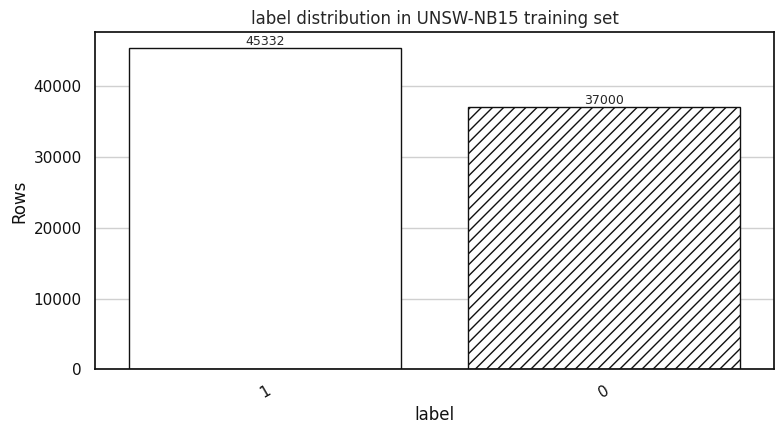

In [5]:
plot_target_distribution(df, TARGET_COL, f"{TARGET_COL} distribution in UNSW-NB15 training set")

## Feature Summaries

In [6]:

# Numeric and categorical summaries
numeric_cols = get_numeric_columns(df, exclude=EXCLUDE_COLS)
categorical_cols = get_categorical_columns(df, exclude=EXCLUDE_COLS)

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

display(df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T if numeric_cols else pd.DataFrame())

categorical_profile = pd.DataFrame({
    "column": categorical_cols,
    "unique_values": [df[c].nunique(dropna=False) for c in categorical_cols],
    "top_value": [df[c].astype("string").fillna("<NA>").mode().iloc[0] if not df[c].mode(dropna=False).empty else None for c in categorical_cols],
    "top_count": [df[c].astype("string").fillna("<NA>").value_counts().iloc[0] if len(df) else 0 for c in categorical_cols],
})
display(categorical_profile.sort_values("unique_values", ascending=False))


Numeric columns: 39
Categorical columns: 3


,count,mean,std,min,1%,5%,50%,95%,99%,max
dur,"82,332.0000",1.0068,4.7104,0.0000,0.0000,0.0000,0.0141,2.4038,22.0483,60.0000
spkts,"82,332.0000",18.6665,133.9164,1.0000,1.0000,2.0000,6.0000,60.0000,208.0000,"10,646.0000"
dpkts,"82,332.0000",17.5459,115.5741,0.0000,0.0000,0.0000,2.0000,54.0000,252.0000,"11,018.0000"
sbytes,"82,332.0000","7,993.9082","171,642.2619",24.0000,46.0000,104.0000,534.0000,"12,472.0000","69,970.0400","14,355,774.0000"
dbytes,"82,332.0000","13,233.7856","151,471.4561",0.0000,0.0000,0.0000,178.0000,"30,622.0000","207,751.0000","14,657,531.0000"
rate,"82,332.0000","82,410.8867","148,620.3670",0.0000,0.0000,9.1615,"2,650.1767","333,333.3215","1,000,000.0030","1,000,000.0030"
sttl,"82,332.0000",180.9677,101.5134,0.0000,0.0000,31.0000,254.0000,254.0000,254.0000,255.0000
dttl,"82,332.0000",95.7130,116.6677,0.0000,0.0000,0.0000,29.0000,252.0000,252.0000,253.0000
sload,"82,332.0000","64,549,016.9141","179,861,832.6300",0.0000,0.0000,"2,865.7026","577,003.2188","266,666,656.0000","800,000,000.0000","5,268,000,256.0000"
dload,"82,332.0000","630,546.9590","2,393,000.5556",0.0000,0.0000,0.0000,"2,112.9514","3,741,445.6000","14,180,870.8300","20,821,108.0000"


,column,unique_values,top_value,top_count
0,proto,131,tcp,43095
1,service,13,-,47153
2,state,7,FIN,39339


## Univariate Patterns

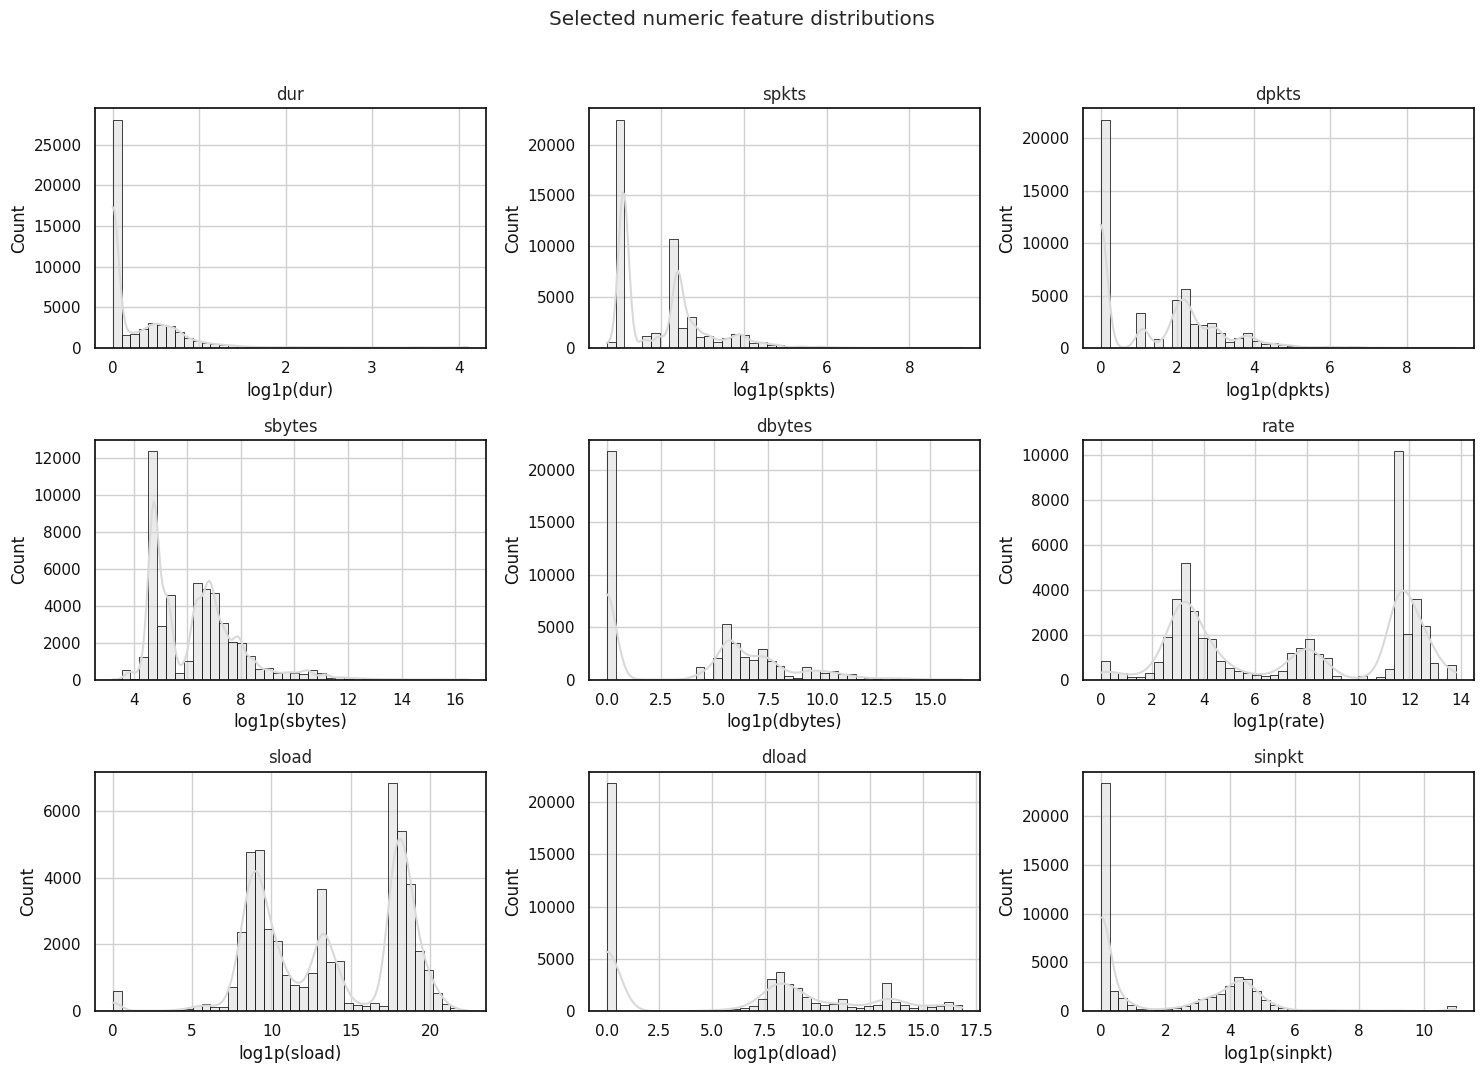

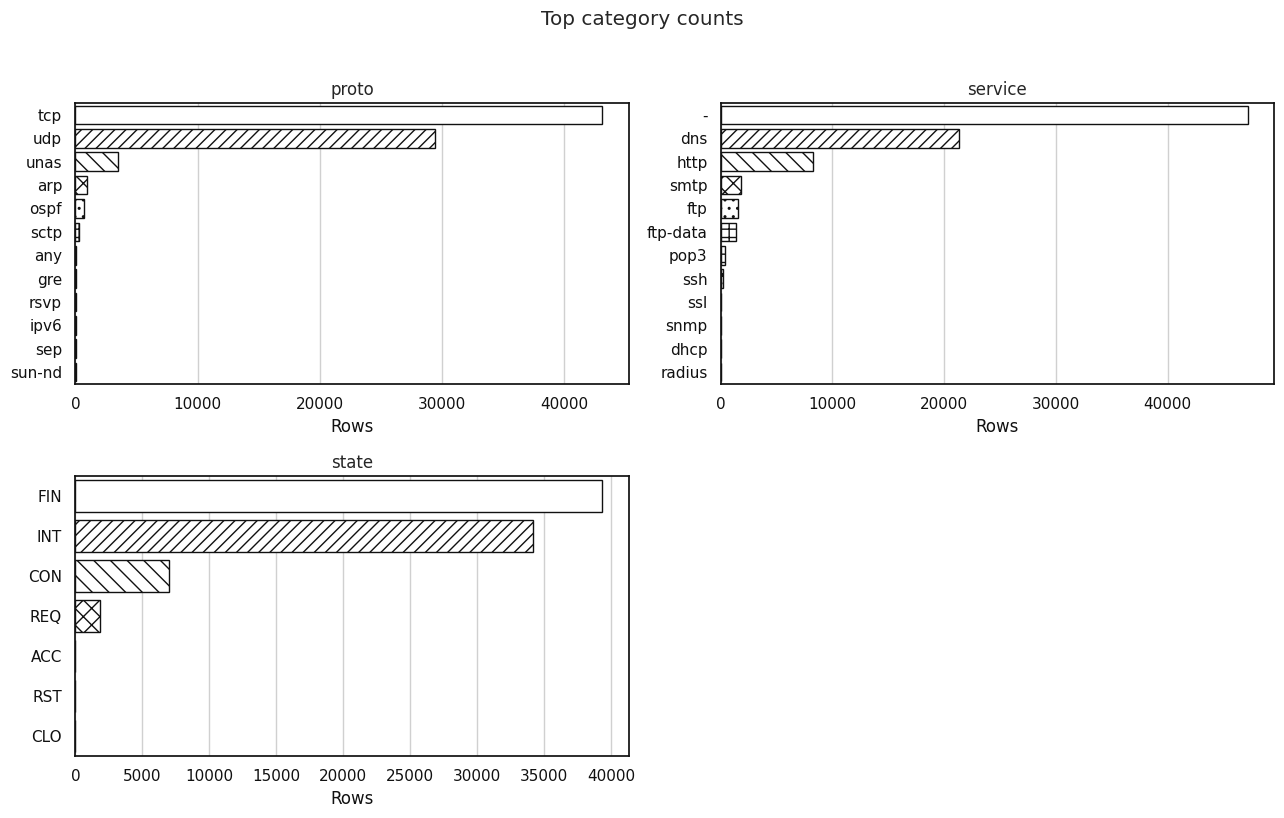

In [7]:
plot_numeric_distributions(df, [c for c in PREFERRED_NUMERIC if c in numeric_cols][:9], "Selected numeric feature distributions")
plot_categorical_top_counts(df, [c for c in PREFERRED_CATEGORICAL if c in categorical_cols][:6], "Top category counts")

## Target Relationships

,absolute_correlation_with_target_code
sttl,0.5042
swin,0.4145
ct_dst_sport_ltm,0.3937
dwin,0.3693
ct_src_dport_ltm,0.3415
rate,0.3286
ct_state_ttl,0.3185
ct_srv_dst,0.2929
ct_srv_src,0.2902
dtcpb,0.2829


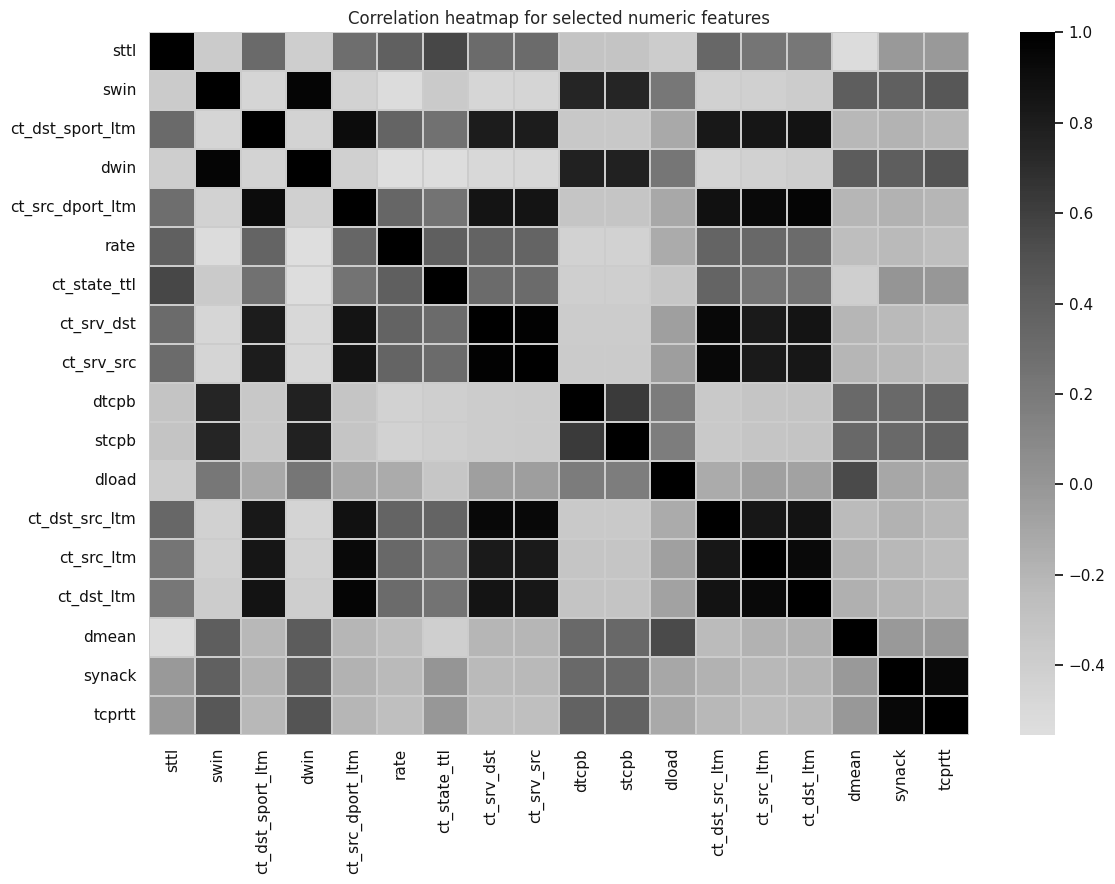

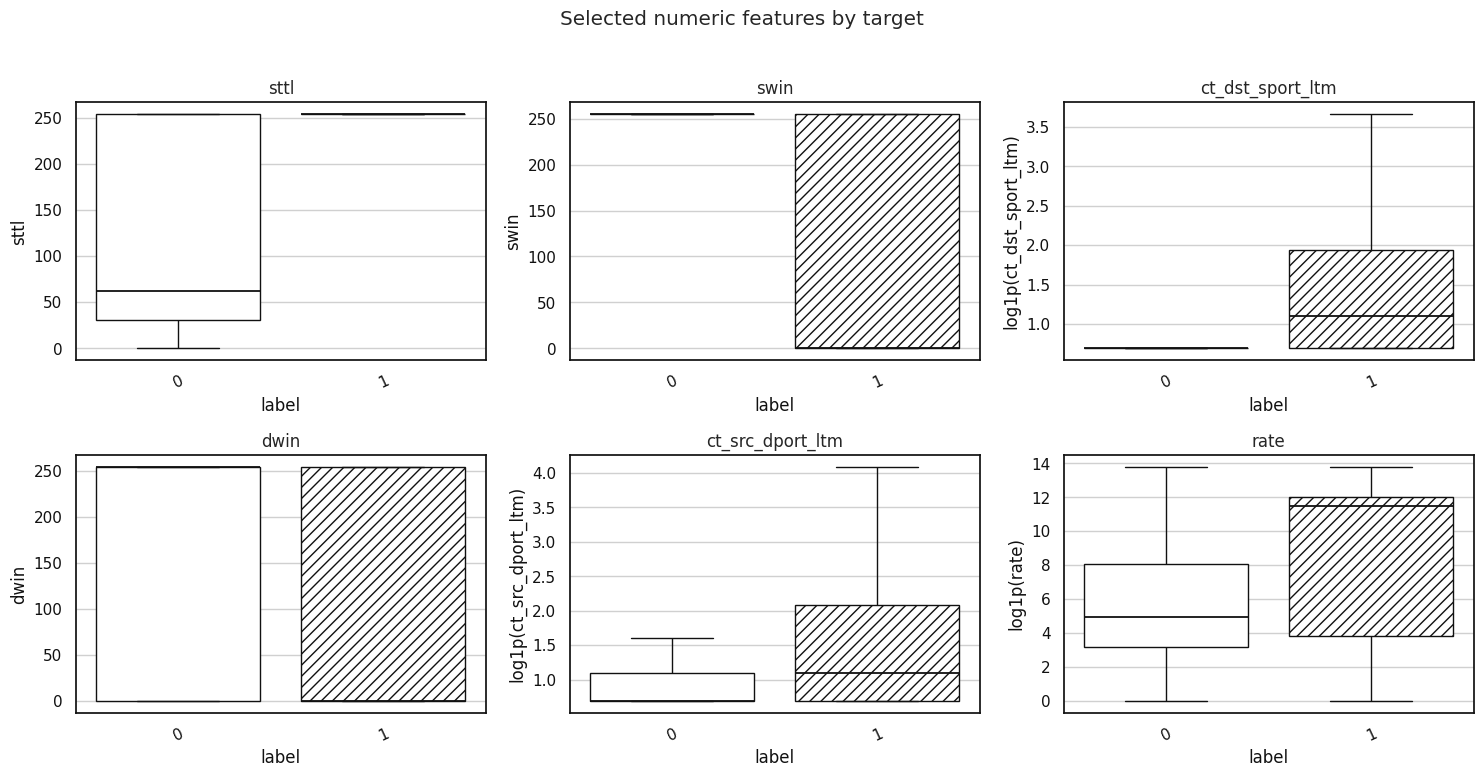

label,0,1
sttl,62.0000,254.0000
swin,255.0000,0.0000
ct_dst_sport_ltm,1.0000,2.0000
dwin,255.0000,0.0000
ct_src_dport_ltm,1.0000,2.0000
rate,118.6255,"100,000.0025"
ct_state_ttl,1.0000,2.0000
ct_srv_dst,4.0000,7.0000
ct_srv_src,4.0000,7.0000
dtcpb,"1,233,811,738.5000",0.0000


In [8]:

# Target associations and correlation structure
assoc = target_association(df, TARGET_COL, numeric_cols, exclude=EXCLUDE_COLS)
display(assoc.head(20).rename("absolute_correlation_with_target_code").to_frame())

selected_numeric = assoc.head(18).index.tolist()
if len(selected_numeric) < 2:
    selected_numeric = numeric_cols[:18]

plot_correlation_heatmap(df, selected_numeric, "Correlation heatmap for selected numeric features")
plot_numeric_by_target(df, TARGET_COL, selected_numeric[:6], "Selected numeric features by target")

if selected_numeric:
    grouped_median = df.groupby(TARGET_COL)[selected_numeric[:10]].median(numeric_only=True).T
    display(grouped_median)


## Advanced EDA

This section extends the baseline EDA with model-preparation checks for the binary `label` target and the multiclass `attack_cat` target: imbalance, duplicate rows, missing/infinite/zero-heavy features, outliers, skewness, class-wise comparisons, correlated pairs, low-variance features, PCA projections, mutual-information feature ranking, and preprocessing recommendations.

In [9]:

from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

ATTACK_CAT_COL = "attack_cat"
ADVANCED_SAMPLE_SIZE = 12_000
PCA_ATTACK_SAMPLE_SIZE = 8_000
CORRELATION_THRESHOLD = 0.85
ZERO_HEAVY_THRESHOLD = 0.90
DOMINANT_VALUE_THRESHOLD = 0.95
LOW_VARIANCE_THRESHOLD = 1e-8

def clean_numeric_frame(data, columns):
    if not columns:
        return pd.DataFrame(index=data.index)
    return data[columns].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

def count_table(data, col):
    counts = data[col].astype("string").fillna("<NA>").value_counts(dropna=False)
    table = counts.rename_axis(col).reset_index(name="count")
    table["percent"] = (table["count"] / len(data) * 100).round(3)
    table["ratio_vs_minority"] = (table["count"] / table["count"].min()).round(3)
    return table

def plot_horizontal_counts(table, label_col, value_col="count", title="Count plot", color="white"):
    if table.empty:
        display(Markdown("No rows available for plotting."))
        return
    plt.figure(figsize=(9, max(3, 0.35 * len(table))))
    ax = sns.barplot(data=table, x=value_col, y=label_col, color="white", edgecolor="#111111")
    apply_bar_hatches(ax)
    plt.title(title)
    plt.xlabel(value_col.replace("_", " ").title())
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

def plot_class_balance(data, col, title, top_n=None, color="white"):
    if col not in data.columns:
        display(Markdown(f"Column `{col}` is not present."))
        return pd.DataFrame()
    table = count_table(data, col)
    display(table)
    plot_table = table.head(top_n) if top_n else table
    plot_horizontal_counts(plot_table, col, "count", title, color=color)
    majority = table.iloc[0]
    minority = table.iloc[-1]
    display(Markdown(
        f"`{col}` has {len(table):,} classes. Majority `{majority[col]}` has {majority['count']:,} rows; "
        f"minority `{minority[col]}` has {minority['count']:,} rows. Majority/minority ratio: "
        f"{majority['ratio_vs_minority']:.3f}:1."
    ))
    return table

def pca_projection(data, numeric_columns, color_col, sample_size, title):
    if color_col not in data.columns:
        display(Markdown(f"Column `{color_col}` is not present, so PCA coloring is skipped."))
        return pd.DataFrame()
    pca_numeric_cols = [
        col for col in numeric_columns
        if data[col].nunique(dropna=True) > 1 and pd.to_numeric(data[col], errors="coerce").notna().any()
    ]
    if len(pca_numeric_cols) < 2:
        display(Markdown("PCA requires at least two non-constant numeric features."))
        return pd.DataFrame()

    pca_sample = sampled(data[[color_col] + pca_numeric_cols], sample_size)
    X_numeric = clean_numeric_frame(pca_sample, pca_numeric_cols)
    X_imputed = SimpleImputer(strategy="median").fit_transform(X_numeric)
    X_scaled = StandardScaler().fit_transform(X_imputed)
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pcs = pca.fit_transform(X_scaled)
    pca_result = pd.DataFrame({
        "PC1": pcs[:, 0],
        "PC2": pcs[:, 1],
        color_col: pca_sample[color_col].astype("string").fillna("<NA>").to_numpy(),
    })
    explained = pca.explained_variance_ratio_ * 100
    display(pd.DataFrame({
        "component": ["PC1", "PC2"],
        "explained_variance_percent": explained.round(3),
    }))

    scatter_with_markers(
        pca_result,
        "PC1",
        "PC2",
        color_col,
        title,
        xlabel=f"PC1 ({explained[0]:.2f}% variance)",
        ylabel=f"PC2 ({explained[1]:.2f}% variance)",
    )
    return pca_result


## Binary Class Imbalance Analysis For Label

,label,count,percent,ratio_vs_minority
0,1,45332,55.0600,1.2250
1,0,37000,44.9400,1.0000


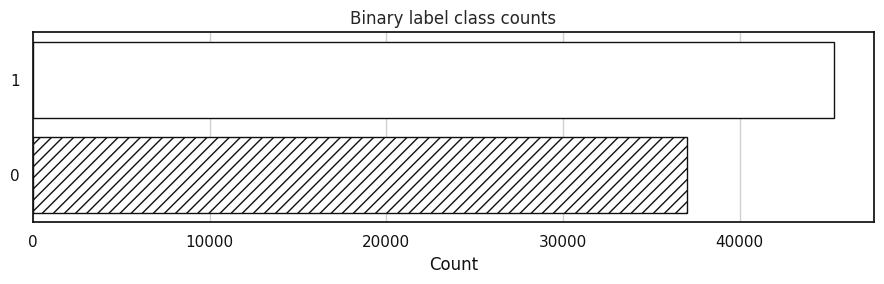

`label` has 2 classes. Majority `1` has 45,332 rows; minority `0` has 37,000 rows. Majority/minority ratio: 1.225:1.

In [10]:

label_balance = plot_class_balance(df, TARGET_COL, "Binary label class counts", color="white")


## Multiclass Imbalance Analysis For Attack Category

,attack_cat,count,percent,ratio_vs_minority
0,Normal,37000,44.9400,840.9090
1,Generic,18871,22.9210,428.8860
2,Exploits,11132,13.5210,253.0000
3,Fuzzers,6062,7.3630,137.7730
4,DoS,4089,4.9660,92.9320
5,Reconnaissance,3496,4.2460,79.4550
6,Analysis,677,0.8220,15.3860
7,Backdoor,583,0.7080,13.2500
8,Shellcode,378,0.4590,8.5910
9,Worms,44,0.0530,1.0000


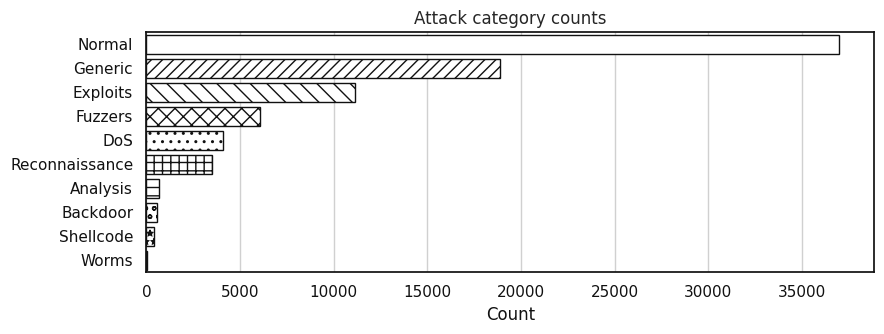

`attack_cat` has 10 classes. Majority `Normal` has 37,000 rows; minority `Worms` has 44 rows. Majority/minority ratio: 840.909:1.

label,0,1,All
attack_cat,,,
Analysis,0,677,677
Backdoor,0,583,583
DoS,0,4089,4089
Exploits,0,11132,11132
Fuzzers,0,6062,6062
Generic,0,18871,18871
Normal,37000,0,37000
Reconnaissance,0,3496,3496
Shellcode,0,378,378


In [11]:

attack_cat_balance = plot_class_balance(df, ATTACK_CAT_COL, "Attack category counts", color="white")

if ATTACK_CAT_COL in df.columns and TARGET_COL in df.columns:
    attack_by_label = pd.crosstab(df[ATTACK_CAT_COL], df[TARGET_COL], margins=True)
    display(attack_by_label)


## Duplicate Row Analysis

In [12]:

duplicate_mask = df.duplicated(keep=False)
duplicate_rows = df[duplicate_mask].copy()

duplicate_summary = pd.DataFrame({
    "metric": ["duplicate_rows_keep_first", "rows_in_duplicate_groups", "duplicate_groups"],
    "value": [
        int(df.duplicated().sum()),
        int(duplicate_mask.sum()),
        int(df[duplicate_mask].value_counts(dropna=False).shape[0]) if duplicate_mask.any() else 0,
    ],
})
display(duplicate_summary)

if duplicate_mask.any():
    duplicate_by_label = (
        duplicate_rows[TARGET_COL]
        .astype("string")
        .fillna("<NA>")
        .value_counts()
        .rename_axis(TARGET_COL)
        .reset_index(name="rows_in_duplicate_groups")
    )
    duplicate_by_label["percent_of_duplicate_rows"] = (duplicate_by_label["rows_in_duplicate_groups"] / len(duplicate_rows) * 100).round(3)
    display(duplicate_by_label)
    plot_horizontal_counts(duplicate_by_label, TARGET_COL, "rows_in_duplicate_groups", "Duplicate rows by label", color="white")

    if ATTACK_CAT_COL in duplicate_rows.columns:
        duplicate_by_attack = (
            duplicate_rows[ATTACK_CAT_COL]
            .astype("string")
            .fillna("<NA>")
            .value_counts()
            .rename_axis(ATTACK_CAT_COL)
            .reset_index(name="rows_in_duplicate_groups")
        )
        duplicate_by_attack["percent_of_duplicate_rows"] = (duplicate_by_attack["rows_in_duplicate_groups"] / len(duplicate_rows) * 100).round(3)
        display(duplicate_by_attack)
else:
    display(Markdown("No duplicate rows found."))


,metric,value
0,duplicate_rows_keep_first,0
1,rows_in_duplicate_groups,0
2,duplicate_groups,0


No duplicate rows found.

## Missing, Infinite, And Zero-Value Analysis

,metric,value
0,infinite_values_before_load_cleanup,0
1,infinite_values_current,0


,dtype,missing_count,missing_percent,infinite_count_current,unique_values,zero_count,zero_percent,is_zero_heavy
is_ftp_login,int64,0,0.0000,0,3,81654,99.1770,True
ct_ftp_cmd,int64,0,0.0000,0,3,81652,99.1740,True
is_sm_ips_ports,int64,0,0.0000,0,2,81416,98.8870,True
response_body_len,int64,0,0.0000,0,1190,76675,93.1290,True
ct_flw_http_mthd,int64,0,0.0000,0,8,74752,90.7930,True
trans_depth,int64,0,0.0000,0,8,74750,90.7910,True
djit,float64,0,0.0000,0,38381,41552,50.4690,False
dloss,int64,0,0.0000,0,311,41204,50.0460,False
ackdat,float64,0,0.0000,0,24020,41160,49.9930,False
tcprtt,float64,0,0.0000,0,26130,41127,49.9530,False


,dtype,zero_count,zero_percent,unique_values
is_ftp_login,int64,81654,99.1770,3
ct_ftp_cmd,int64,81652,99.1740,3
is_sm_ips_ports,int64,81416,98.8870,2
response_body_len,int64,76675,93.1290,1190
ct_flw_http_mthd,int64,74752,90.7930,8
trans_depth,int64,74750,90.7910,8


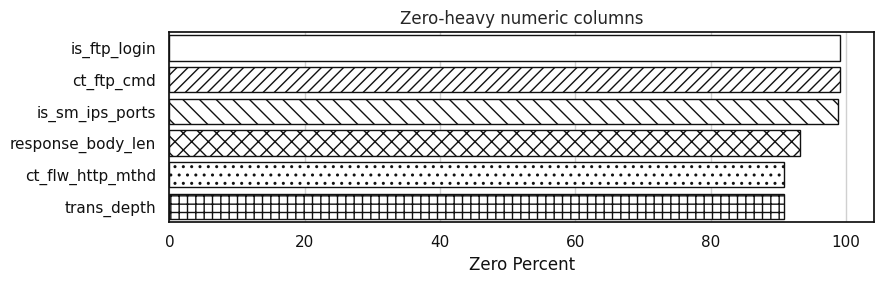

In [13]:

numeric_for_quality = clean_numeric_frame(df, numeric_cols)
missing_counts = df.isna().sum()
current_inf_counts = pd.Series(0, index=df.columns, dtype="int64")
if numeric_cols:
    current_inf_counts.loc[numeric_cols] = np.isinf(df[numeric_cols].select_dtypes(include=np.number).to_numpy()).sum(axis=0)

quality_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": missing_counts,
    "missing_percent": (missing_counts / len(df) * 100).round(3),
    "infinite_count_current": current_inf_counts,
    "unique_values": df.nunique(dropna=False),
})

zero_counts = numeric_for_quality.eq(0).sum()
zero_percent = (zero_counts / len(df) * 100).round(3)
quality_table["zero_count"] = 0
quality_table["zero_percent"] = 0.0
quality_table.loc[zero_counts.index, "zero_count"] = zero_counts.astype(int)
quality_table.loc[zero_percent.index, "zero_percent"] = zero_percent
quality_table["is_zero_heavy"] = quality_table["zero_percent"] >= ZERO_HEAVY_THRESHOLD * 100
quality_table = quality_table.sort_values(["missing_percent", "infinite_count_current", "zero_percent"], ascending=False)

display(pd.DataFrame({
    "metric": ["infinite_values_before_load_cleanup", "infinite_values_current"],
    "value": [int(globals().get("inf_count", 0)), int(quality_table["infinite_count_current"].sum())],
}))
display(quality_table.head(30))

zero_heavy_columns = quality_table[quality_table["is_zero_heavy"]].sort_values("zero_percent", ascending=False)
display(zero_heavy_columns[["dtype", "zero_count", "zero_percent", "unique_values"]])

if not zero_heavy_columns.empty:
    plot_table = zero_heavy_columns.reset_index(names="column").head(20)
    plot_horizontal_counts(plot_table, "column", "zero_percent", "Zero-heavy numeric columns", color="white")
else:
    display(Markdown(f"No numeric columns have at least {ZERO_HEAVY_THRESHOLD:.0%} zero values."))


## IQR Outlier Detection Summary

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent,non_null
9,dload,0.0000,"15,858.0823","15,858.0823","-23,787.1234","39,645.2057",18112,21.9990,82332
32,ct_dst_src_ltm,1.0000,6.0000,5.0000,-6.5000,13.5000,12789,15.5330,82332
4,dbytes,0.0000,956.0000,956.0000,"-1,434.0000","2,390.0000",12308,14.9490,82332
23,smean,57.0000,100.0000,43.0000,-7.5000,164.5000,11928,14.4880,82332
30,ct_src_dport_ltm,1.0000,4.0000,3.0000,-3.5000,8.5000,11476,13.9390,82332
11,dloss,0.0000,2.0000,2.0000,-3.0000,5.0000,11272,13.6910,82332
31,ct_dst_sport_ltm,1.0000,3.0000,2.0000,-2.0000,6.0000,10907,13.2480,82332
29,ct_dst_ltm,1.0000,6.0000,5.0000,-6.5000,13.5000,10479,12.7280,82332
1,spkts,2.0000,12.0000,10.0000,-13.0000,27.0000,10196,12.3840,82332
27,ct_srv_src,2.0000,11.0000,9.0000,-11.5000,24.5000,10093,12.2590,82332


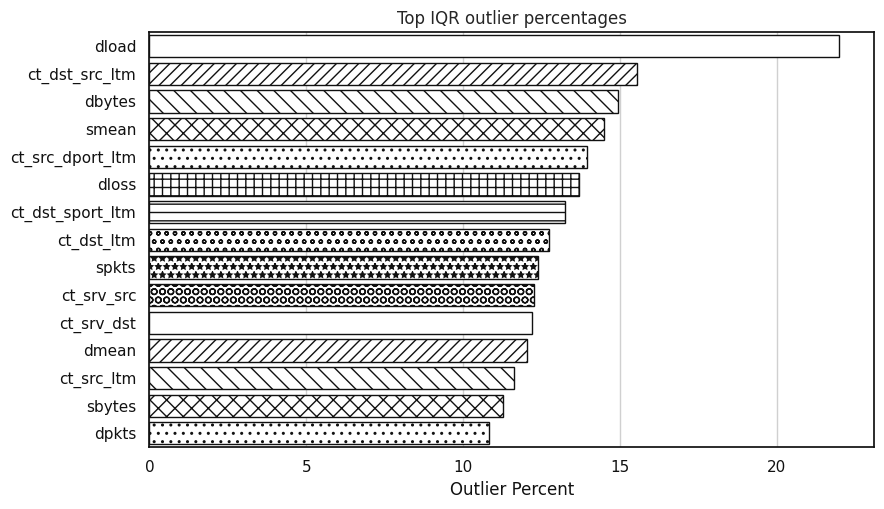

In [14]:

outlier_rows = []
for col in numeric_cols:
    values = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if values.empty:
        continue
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    if np.isclose(iqr, 0):
        outlier_count = 0
    else:
        outlier_count = int(((values < lower) | (values > upper)).sum())
    outlier_rows.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_percent": round(outlier_count / len(values) * 100, 3),
        "non_null": int(values.shape[0]),
    })

iqr_outlier_table = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(iqr_outlier_table.head(30))

plot_iqr = iqr_outlier_table[iqr_outlier_table["outlier_count"] > 0].head(15)
if not plot_iqr.empty:
    plot_horizontal_counts(plot_iqr, "column", "outlier_percent", "Top IQR outlier percentages", color="white")
else:
    display(Markdown("No IQR outliers detected after excluding zero-IQR columns."))


## Skewness Analysis For Numeric Features

,skewness,abs_skewness
trans_depth,170.7944,170.7944
response_body_len,74.6352,74.6352
djit,60.5623,60.5623
dloss,54.4656,54.4656
sbytes,53.7785,53.7785
dbytes,52.5504,52.5504
sloss,52.4653,52.4653
dpkts,49.3041,49.3041
spkts,47.7478,47.7478
dinpkt,23.0130,23.0130


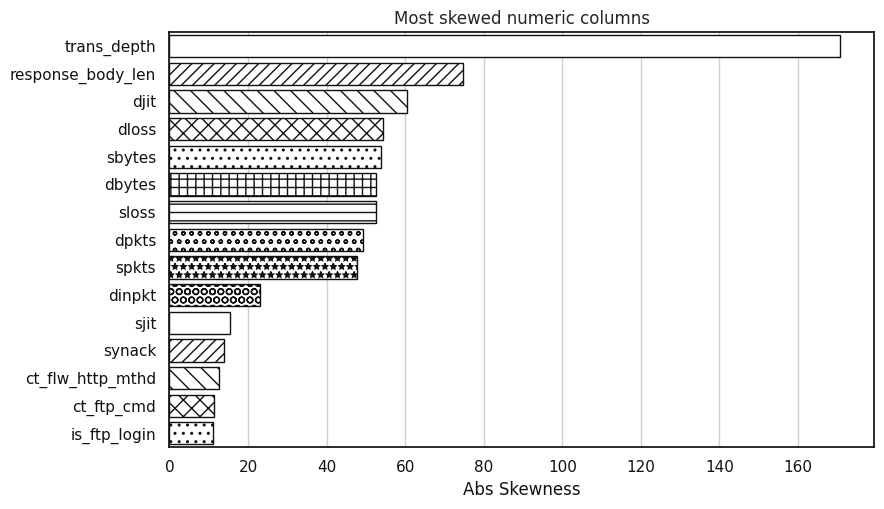

In [15]:

skew_values = clean_numeric_frame(df, numeric_cols).skew(numeric_only=True).dropna()
skewness_table = (
    skew_values.rename("skewness")
    .to_frame()
    .assign(abs_skewness=lambda x: x["skewness"].abs())
    .sort_values("abs_skewness", ascending=False)
)
display(skewness_table.head(30))

plot_skew = skewness_table.head(15).reset_index(names="column")
if not plot_skew.empty:
    plot_horizontal_counts(plot_skew, "column", "abs_skewness", "Most skewed numeric columns", color="white")


## Class-Wise Feature Comparison Plots

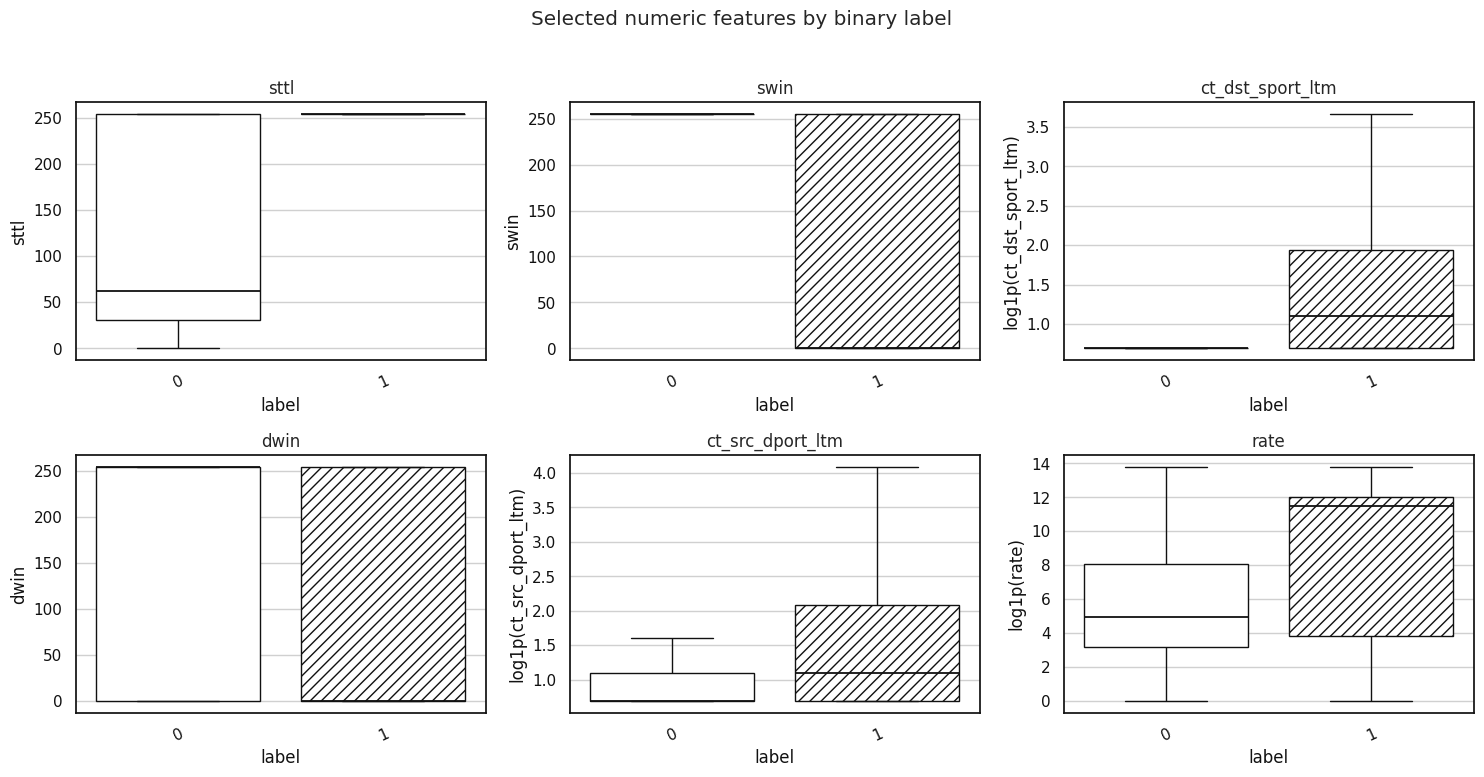

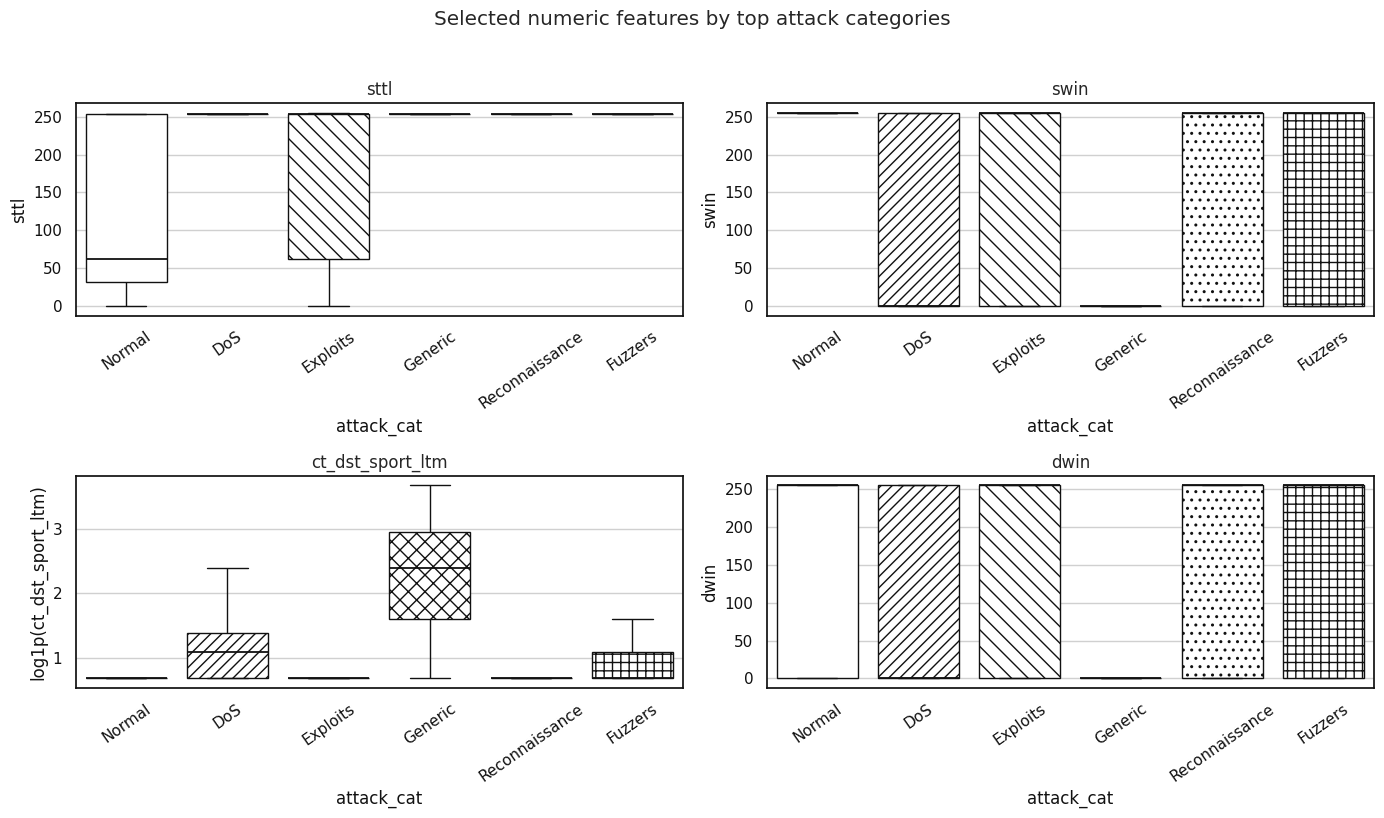

In [16]:

# Prefer features already associated with the binary target; fall back to common traffic-volume/timing features.
if 'assoc' in globals() and not assoc.empty:
    classwise_features = [c for c in assoc.head(6).index if c in numeric_cols]
else:
    classwise_features = [c for c in PREFERRED_NUMERIC if c in numeric_cols][:6]

plot_numeric_by_target(df, TARGET_COL, classwise_features, "Selected numeric features by binary label")

if ATTACK_CAT_COL in df.columns:
    top_attack_categories = df[ATTACK_CAT_COL].astype("string").value_counts().head(6).index.tolist()
    attack_sample = sampled(df[df[ATTACK_CAT_COL].astype("string").isin(top_attack_categories)], 30_000)
    features_to_plot = classwise_features[:4]
    if features_to_plot:
        n_cols = 2
        n_rows = int(np.ceil(len(features_to_plot) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows))
        axes = np.array(axes).reshape(-1)
        for ax, col in zip(axes, features_to_plot):
            plot_data = attack_sample[[ATTACK_CAT_COL, col]].copy()
            plot_data[col] = pd.to_numeric(plot_data[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
            plot_data = plot_data.dropna(subset=[col])
            ylabel = col
            if not plot_data.empty and plot_data[col].min() >= 0 and plot_data[col].quantile(0.99) > max(plot_data[col].median() * 10, 10):
                plot_data[col] = np.log1p(plot_data[col])
                ylabel = f"log1p({col})"
            boxplot_print(plot_data, ATTACK_CAT_COL, col, ax=ax, showfliers=False)
            ax.set_title(col)
            ax.set_ylabel(ylabel)
            ax.tick_params(axis="x", rotation=35)
        for ax in axes[len(features_to_plot):]:
            ax.set_visible(False)
        fig.suptitle("Selected numeric features by top attack categories", y=1.02)
        plt.tight_layout()
        plt.show()


## Highly Correlated Feature Pair Detection

In [17]:

numeric_clean = clean_numeric_frame(df, numeric_cols)
corr_matrix = numeric_clean.corr().abs()
upper_mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
correlated_pairs = (
    corr_matrix.where(upper_mask)
    .stack()
    .rename("absolute_correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
    .sort_values("absolute_correlation", ascending=False)
)
highly_correlated_pairs = correlated_pairs[correlated_pairs["absolute_correlation"] >= CORRELATION_THRESHOLD]
display(highly_correlated_pairs.head(40))
display(Markdown(f"Found {len(highly_correlated_pairs):,} numeric feature pairs with absolute correlation >= {CORRELATION_THRESHOLD:.2f}."))


,feature_1,feature_2,absolute_correlation
167,dbytes,dloss,0.9971
127,sbytes,sloss,0.9950
1321,is_ftp_login,ct_ftp_cmd,0.9943
89,dpkts,dloss,0.9815
1090,ct_srv_src,ct_srv_dst,0.9778
82,dpkts,dbytes,0.9764
49,spkts,sloss,0.9736
42,spkts,sbytes,0.9657
1161,ct_dst_ltm,ct_src_dport_ltm,0.9604
643,swin,dwin,0.9601


Found 24 numeric feature pairs with absolute correlation >= 0.85.

## Low-Variance And Constant Column Detection

In [18]:

low_variance_rows = []
for col in [c for c in df.columns if c not in {TARGET_COL, ATTACK_CAT_COL}]:
    series = df[col]
    value_counts = series.astype("string").fillna("<NA>").value_counts(dropna=False)
    dominant_percent = float(value_counts.iloc[0] / len(series) * 100) if len(value_counts) else np.nan
    unique_values = int(series.nunique(dropna=False))
    row = {
        "column": col,
        "dtype": str(series.dtype),
        "unique_values": unique_values,
        "is_constant": unique_values <= 1,
        "dominant_value": value_counts.index[0] if len(value_counts) else None,
        "dominant_percent": round(dominant_percent, 3),
        "near_constant_by_dominance": dominant_percent >= DOMINANT_VALUE_THRESHOLD * 100 if len(value_counts) else False,
    }
    if pd.api.types.is_numeric_dtype(series):
        values = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
        row["variance"] = float(values.var(skipna=True)) if values.notna().any() else np.nan
        row["zero_or_near_zero_variance"] = bool(pd.notna(row["variance"]) and row["variance"] <= LOW_VARIANCE_THRESHOLD)
    else:
        row["variance"] = np.nan
        row["zero_or_near_zero_variance"] = False
    low_variance_rows.append(row)

low_variance_table = pd.DataFrame(low_variance_rows).sort_values(
    ["is_constant", "zero_or_near_zero_variance", "near_constant_by_dominance", "dominant_percent"],
    ascending=[False, False, False, False],
)
display(low_variance_table.head(35))

low_variance_candidates = low_variance_table[
    low_variance_table["is_constant"] |
    low_variance_table["zero_or_near_zero_variance"] |
    low_variance_table["near_constant_by_dominance"]
]
display(low_variance_candidates)


,column,dtype,unique_values,is_constant,dominant_value,dominant_percent,near_constant_by_dominance,variance,zero_or_near_zero_variance
37,is_ftp_login,int64,3,False,0,99.1770,True,0.0083,False
38,ct_ftp_cmd,int64,3,False,0,99.1740,True,0.0086,False
42,is_sm_ips_ports,int64,2,False,0,98.8870,True,0.0110,False
30,response_body_len,int64,1190,False,0,93.1290,False,"1,449,094,379.4527",False
39,ct_flw_http_mthd,int64,8,False,0,90.7930,False,0.4079,False
29,trans_depth,int64,8,False,0,90.7910,False,0.2948,False
10,sttl,int64,11,False,254,65.6480,False,"10,304.9618",False
35,ct_dst_sport_ltm,int64,33,False,1,65.4460,False,34.9918,False
3,service,str,13,False,-,57.2720,False,NaN,False
34,ct_src_dport_ltm,int64,50,False,1,52.4470,False,70.3845,False


,column,dtype,unique_values,is_constant,dominant_value,dominant_percent,near_constant_by_dominance,variance,zero_or_near_zero_variance
37,is_ftp_login,int64,3,False,0,99.1770,True,0.0083,False
38,ct_ftp_cmd,int64,3,False,0,99.1740,True,0.0086,False
42,is_sm_ips_ports,int64,2,False,0,98.8870,True,0.0110,False


## PCA 2D Visualization Colored By Label

,component,explained_variance_percent
0,PC1,24.1240
1,PC2,9.8820


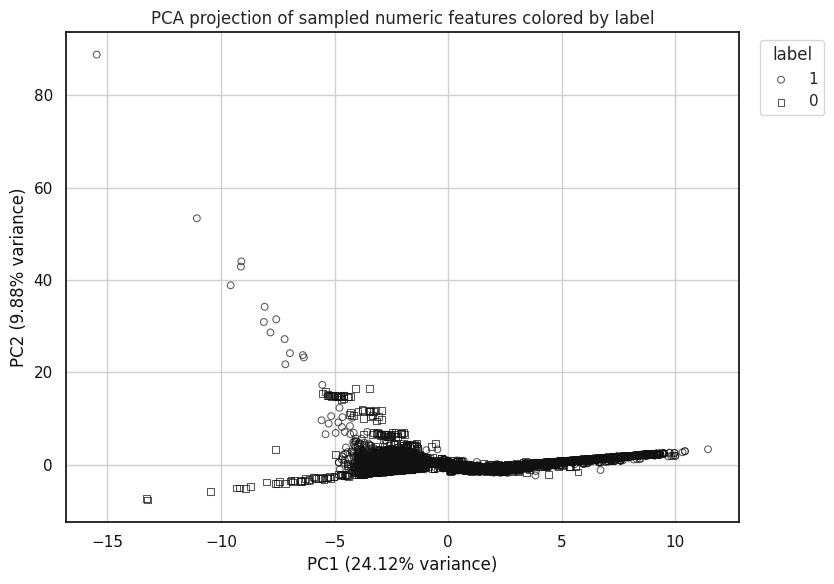

In [19]:

pca_label_result = pca_projection(
    df,
    numeric_cols,
    TARGET_COL,
    ADVANCED_SAMPLE_SIZE,
    "PCA projection of sampled numeric features colored by label",
)


## Optional PCA Colored By Attack Category

,component,explained_variance_percent
0,PC1,24.3850
1,PC2,10.6760


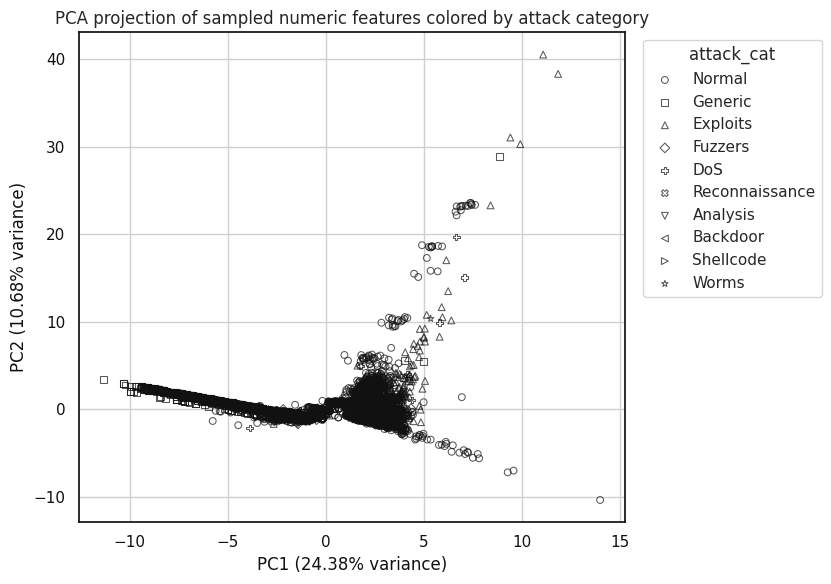

In [20]:

if ATTACK_CAT_COL in df.columns:
    pca_attack_result = pca_projection(
        df,
        numeric_cols,
        ATTACK_CAT_COL,
        PCA_ATTACK_SAMPLE_SIZE,
        "PCA projection of sampled numeric features colored by attack category",
    )
else:
    pca_attack_result = pd.DataFrame()
    display(Markdown("`attack_cat` is not present, so attack-category PCA is skipped."))


## Feature Ranking Using Mutual Information

,feature,mutual_information_with_label,feature_type
0,id,0.6879,numeric
1,sbytes,0.4607,numeric
2,smean,0.3584,numeric
3,sload,0.3449,numeric
4,dbytes,0.2924,numeric
5,ct_state_ttl,0.2783,numeric
6,rate,0.2629,numeric
7,dur,0.2538,numeric
8,dmean,0.2487,numeric
9,dttl,0.2423,numeric


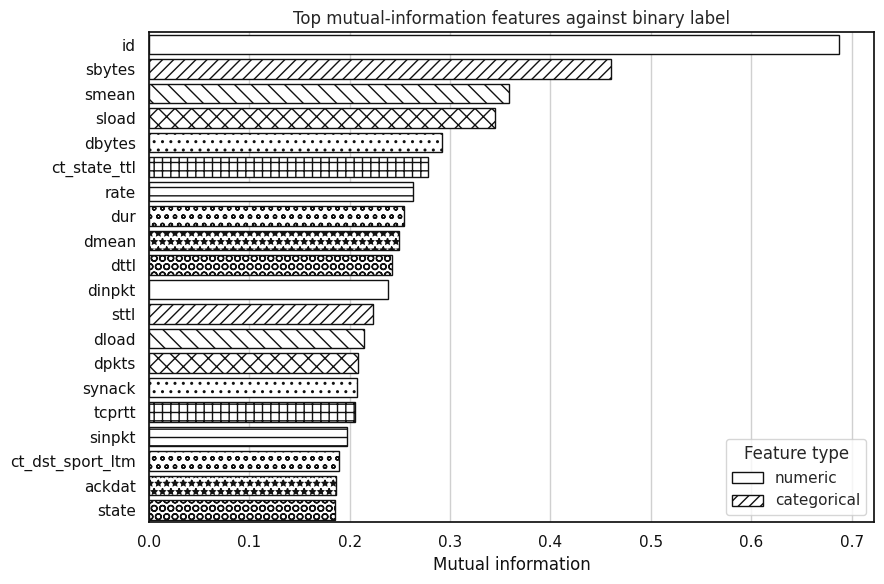

In [21]:

feature_cols = [c for c in df.columns if c not in {TARGET_COL, ATTACK_CAT_COL}]
y_label = pd.Series(pd.factorize(df[TARGET_COL].astype("string").fillna("<NA>"))[0], index=df.index)

X_parts = []
discrete_features = []
encoded_feature_names = []

for col in feature_cols:
    series = df[col]
    if pd.api.types.is_numeric_dtype(series):
        values = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
        fill_value = values.median() if values.notna().any() else 0
        X_parts.append(values.fillna(fill_value).to_numpy())
        discrete_features.append(False)
    else:
        encoded = pd.factorize(series.astype("string").fillna("<NA>"))[0]
        X_parts.append(encoded)
        discrete_features.append(True)
    encoded_feature_names.append(col)

if not X_parts:
    mi_feature_ranking = pd.DataFrame()
    display(Markdown("No predictors available for mutual information ranking."))
else:
    X_mi = np.column_stack(X_parts)
    mi_scores = mutual_info_classif(
        X_mi,
        y_label,
        discrete_features=np.array(discrete_features, dtype=bool),
        random_state=RANDOM_STATE,
    )
    mi_feature_ranking = (
        pd.DataFrame({
            "feature": encoded_feature_names,
            "mutual_information_with_label": mi_scores,
            "feature_type": ["categorical" if flag else "numeric" for flag in discrete_features],
        })
        .sort_values("mutual_information_with_label", ascending=False)
        .reset_index(drop=True)
    )
    display(mi_feature_ranking.head(30))

    plt.figure(figsize=(9, 6))
    ax = sns.barplot(
        data=mi_feature_ranking.head(20),
        x="mutual_information_with_label",
        y="feature",
        hue="feature_type",
        dodge=False,
        palette=print_palette(2),
        edgecolor="#111111",
    )
    apply_bar_hatches(ax)
    plt.title("Top mutual-information features against binary label")
    plt.xlabel("Mutual information")
    plt.ylabel("")
    plt.legend(title="Feature type")
    plt.tight_layout()
    plt.show()
